# Лабораторная работа №6
# "Прогнозирование рейтинга фильмов на КиноПоиске"

ЦЕЛЬ РАБОТЫ - предсказать рейтинг фильма

РЕШАЕМАЯ ЗАДАЧА - подобрать и обучить модель НЕЙРОННОЙ СЕТИ способную предсказать рейтинг фильма на основе имеющихся (данных) признаков

ХОД РАБОТЫ

1) Анализ и предобработка
2) Построение baseline-модели нейронной сети
3) Доработка модели
4) Визуализация и сравнение результатов
5) Вывод по работе

ОПИСАНИЕ ДАННЫХ

Таблица mkrf_movies содержит информацию из реестра прокатных удостоверений:

- title — название фильма;
- puNumber — номер прокатного удостоверения;
- show_start_date — дата премьеры фильма;
- type — тип фильма;
- film_studio — студия-производитель;
- production_country — страна-производитель;
- director — режиссёр;
- producer — продюсер;
- age_restriction — возрастная категория;
- refundable_support — объём возвратных средств государственной поддержки;
- nonrefundable_support — объём невозвратных средств государственной поддержки;
- financing_source — источник государственного финансирования;
- budget — общий бюджет фильма;
- ratings — рейтинг фильма на КиноПоиске;
- genres — жанр фильма.

(У одного фильма может быть несколько прокатных удостоверений)

Таблица mkrf_shows содержит сведения о показах фильмов в российских кинотеатрах:

- puNumber — номер прокатного удостоверения;
- box_office — сборы в рублях.

## Импорт необходимых пакетов

<div class="alert alert-info">
<b>Перед началом работы над проектом установим и импортируем все необходимые пакеты</b>
<br>
</div>

In [1]:
import pandas as pd
import numpy as np
import phik
import math
import warnings

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st
from scipy.stats import binom, poisson
import shap

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from scipy.spatial.distance import cosine
from scipy.spatial.distance import euclidean

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import recall_score, precision_score, accuracy_score
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc, confusion_matrix
from sklearn.metrics import confusion_matrix

from phik import phik_matrix
from phik.report import plot_correlation_matrix

RANDOM_STATE = 42
TEST_SIZE = 0.25
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from keras.models import Sequential
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.wrappers.scikit_learn import KerasRegressor

## Шаг 1. Анализ и предобработка

In [2]:
def check_data(name_csv):
    print('Общая информация **************************************************************************************************************************')
    print(name_csv.info())
    print('Первые пять строк *************************************************************************************************************************')
    print(name_csv.head())
    print('Название столбцов *************************************************************************************************************************')
    print(name_csv.columns)
    print('Число пропущенных значений  ***************************************************************************************************************')
    print(name_csv.isna().sum())
    print('Число ЯВНЫХ дубликатов ********************************************************************************************************************')
    print(name_csv.duplicated().sum())
    display(name_csv.describe().T)
    name_csv.hist(figsize=(15, 20))
    display(name_csv)

<div class="alert alert-info">
<b>Таблица mkrf_movies</b>
<br>
</div>

In [3]:
mkrf_movies = pd.read_csv('mkrf_movies.csv', sep = ',')

In [4]:
# mkrf_movies

Общая информация **************************************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source    

,count,mean,std,min,25%,50%,75%,max
refundable_support,332.0,1.186446e+07,2.491656e+07,0.0,0.0,0.0,15000000.0,1.800000e+08
nonrefundable_support,332.0,4.898099e+07,5.998012e+07,0.0,25000000.0,30000000.0,40375000.0,4.000000e+08
budget,332.0,1.272297e+08,1.885883e+08,0.0,42000000.0,68649916.0,141985319.5,2.305074e+09


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7481,Сад художника: Американский импрессионизм,126008019,2019-12-23T12:00:00.000Z,Прочие,Севен Артс Продакшнз,Великобритания,Фил Грабски,Фил Грабски,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,NaN,NaN
7482,Звериная ярость,121037819,2019-12-24T12:00:00.000Z,Художественный,"Дэниел Гродник Продакшнз, Вандерфилм Медиа Кор...",США,Ник Пауэлл,"Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэ...",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.4,"боевик,триллер"
7483,Щенячий патруль: Скорей спешим на помощь!,124010819,2019-12-28T12:00:00.000Z,Художественный,"Никелодеон Анимейшн Студиос, Спин Мастер",США - Канада,Чарльз Е.Бастьен,Дженнифер Додж,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN
7484,"Машины песенки. Серия ""Испанские мотивы""",124010619,2019-12-30T12:00:00.000Z,Анимационный,"Анимаккорд Лтд., ООО Студия ""АНИМАККОРД""","Республика Кипр, Россия",А.Беляев,Д.Ловейко,«0+» - для любой зрительской аудитории,NaN,NaN,NaN,NaN,NaN,NaN


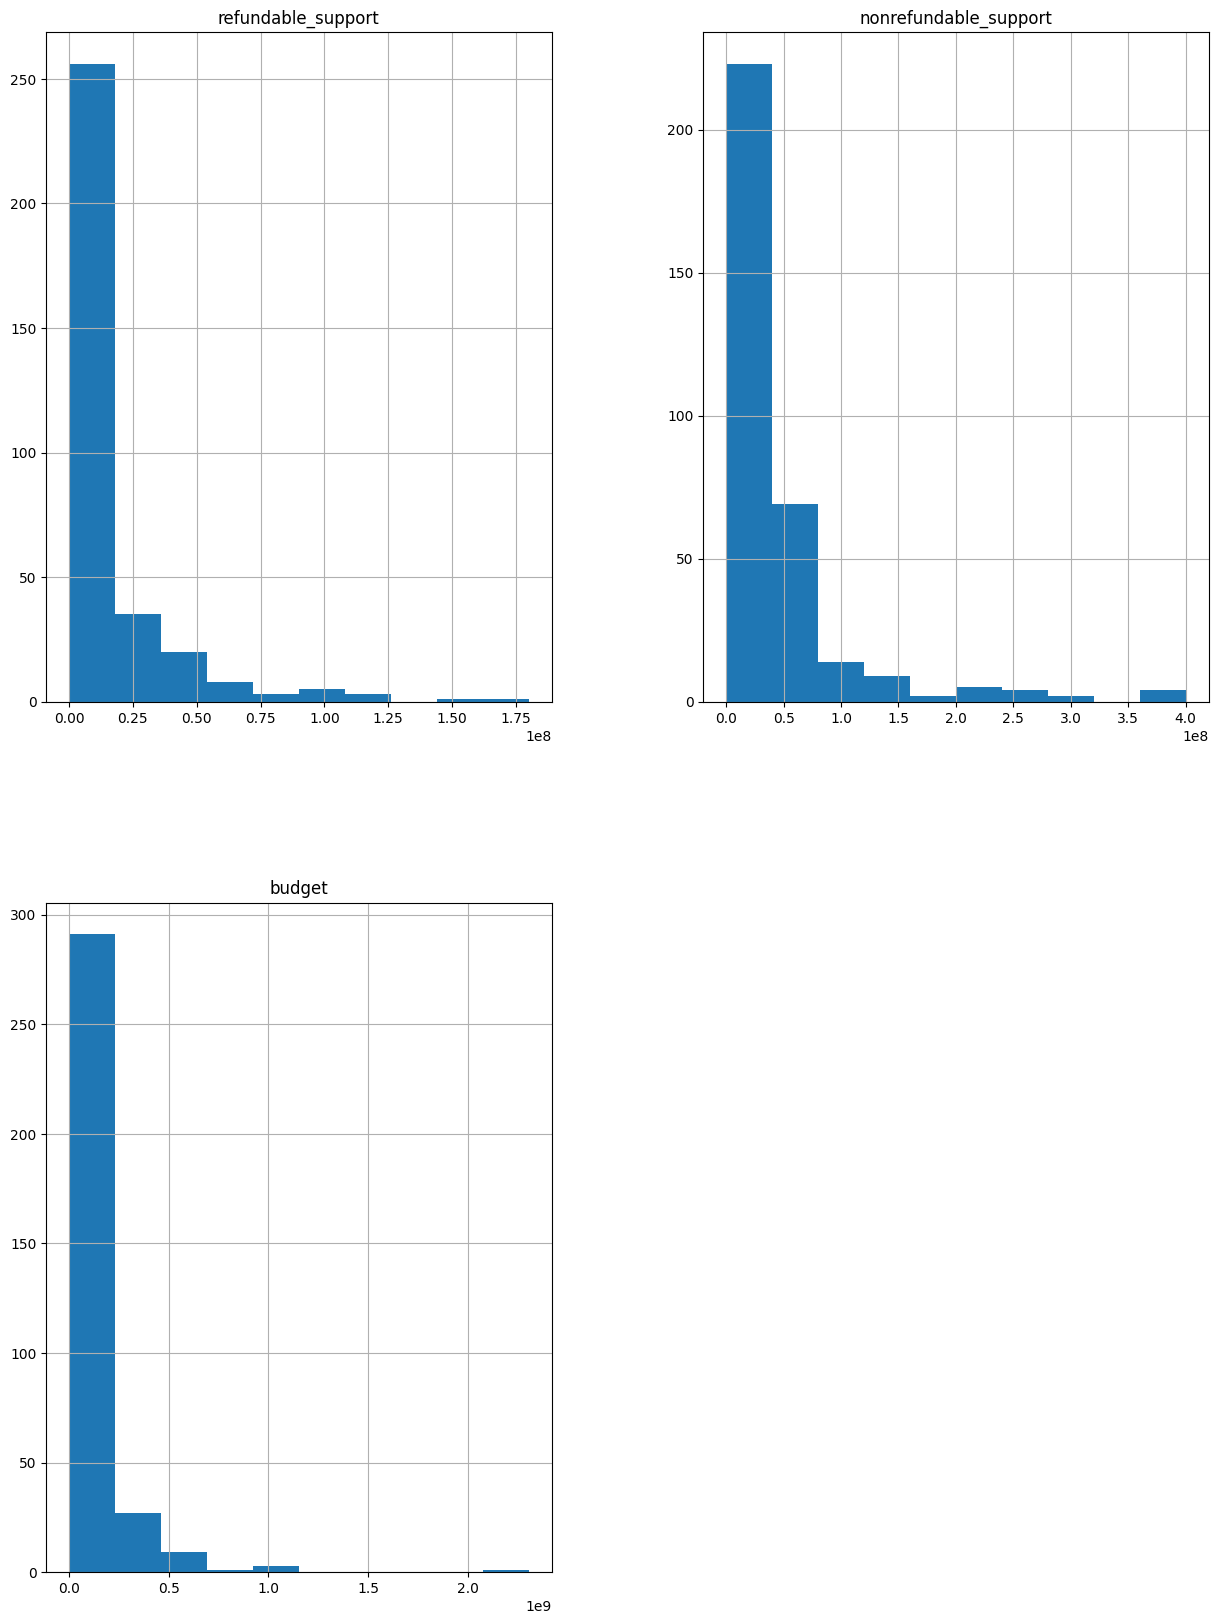

In [5]:
check_data(mkrf_movies)

<div class="alert alert-info">
<b>Таблица mkrf_shows</b>
<br>
</div>

In [6]:
mkrf_shows = pd.read_csv('mkrf_shows.csv', sep = ',')

In [7]:
# mkrf_shows

Общая информация **************************************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB
None
Первые пять строк *************************************************************************************************************************
    puNumber    box_office
0  111000113  2.450000e+03
1  111000115  6.104000e+04
2  111000116  1.530300e+08
3  111000117  1.226096e+07
4  111000118  1.636841e+08
Название столбцов *************************************************************************************************************************
Index(['puNumber', 'box_office'], dtype='object')
Число пропущенных значений  **************

,count,mean,std,min,25%,50%,75%,max
puNumber,3158.0,1.201875e+08,1.238394e+07,111000113.0,1.130002e+08,1.210131e+08,1.210283e+08,2.240264e+08
box_office,3158.0,7.647870e+07,2.403531e+08,0.0,8.623900e+04,2.327988e+06,2.397967e+07,3.073569e+09


,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08
...,...,...
3153,224014814,1.530000e+03
3154,224021411,9.270000e+03
3155,224022410,4.000000e+02
3156,224023210,3.600000e+02


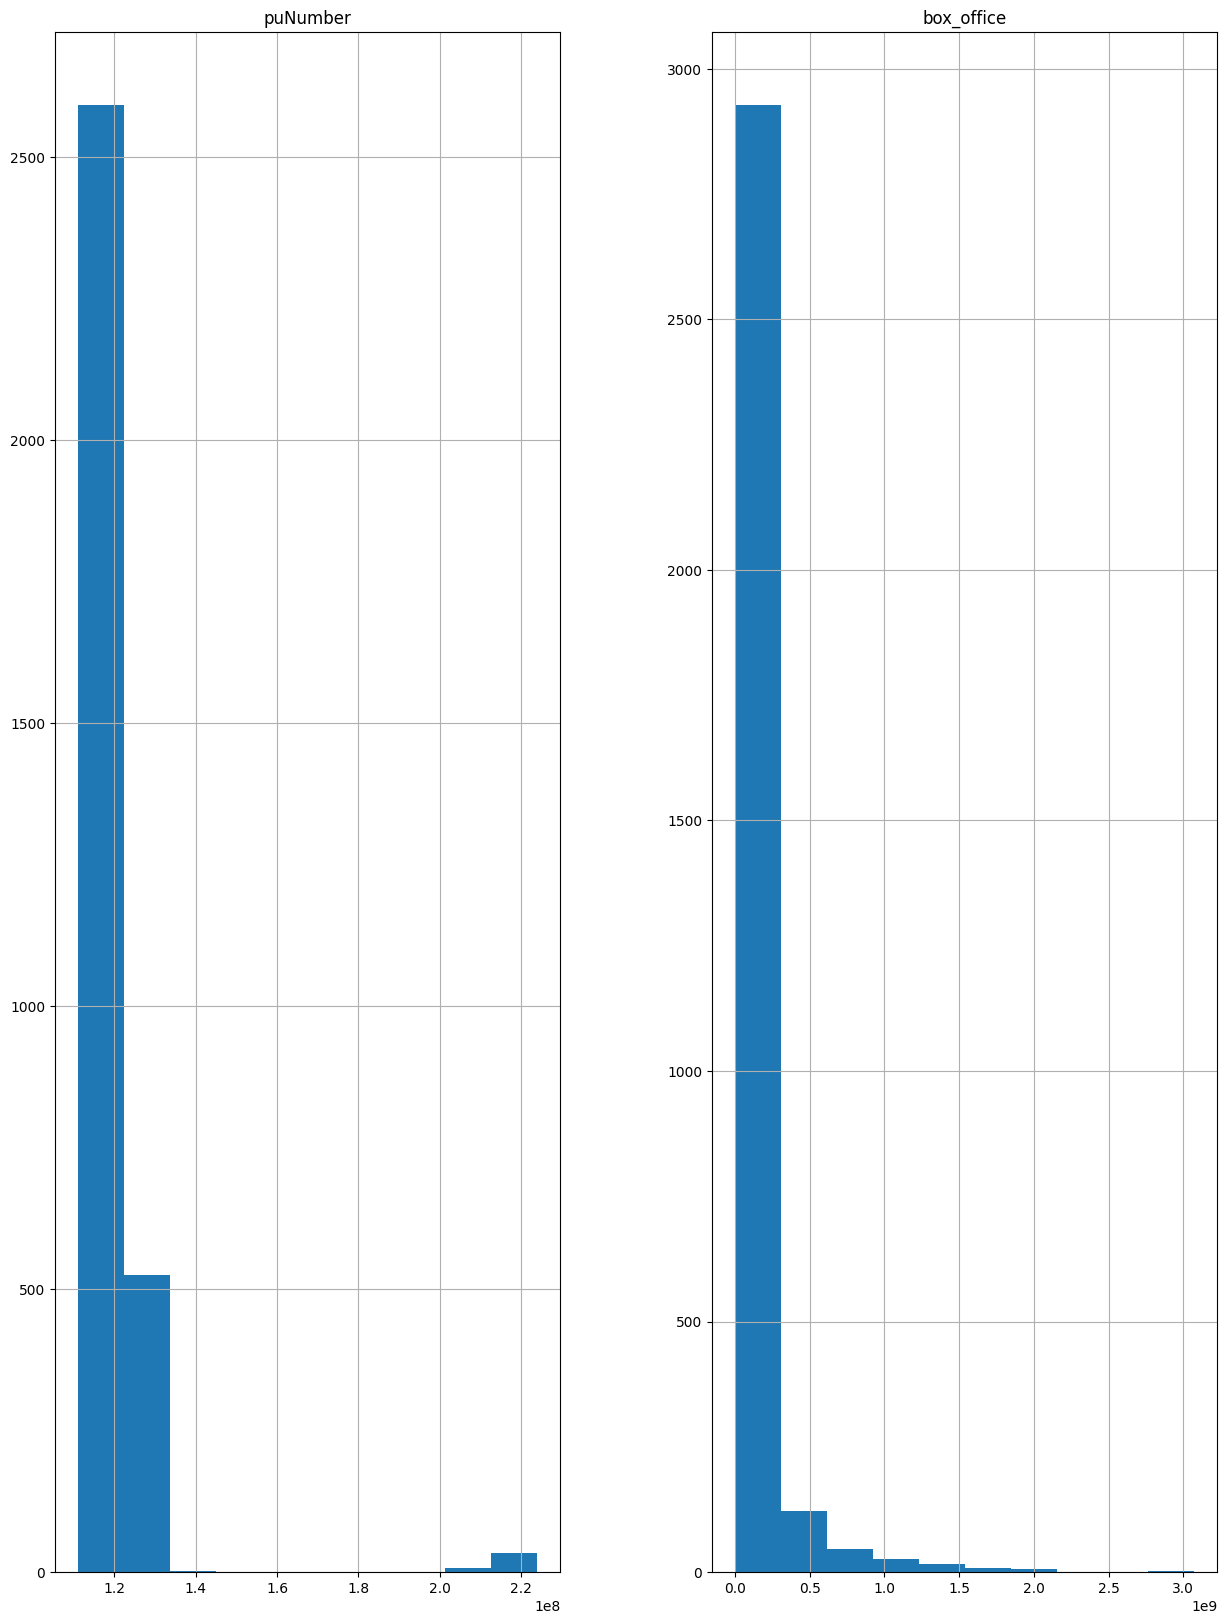

In [8]:
check_data(mkrf_shows)

<div class="alert alert-info">
<b>Ниже займемся предобработкой, разберемся сначала с типами данных)</b>
<br>
</div>

- title - название фильма - тип данных object, ОСТАВЛЯЕМ КАК ЕСТЬ (нет пропусков)
- puNumber - номер прокатного удостоверения - тип данных object ---> меняем на int64 (нет пропусков)
- show_start_date - дата премьеры фильма - object ---> меняем на int64 и оставим только год выпуска (нет пропусков)
- type - тип фильма - object - ОСТАВЛЯЕМ КАК ЕСТЬ (нет пропусков)
- film_studio - студия-производитель - object - ОСТАВЛЯЕМ КАК ЕСТЬ (есть пропуски)
- production_country — страна-производитель - object - ОСТАВЛЯЕМ КАК ЕСТЬ (есть пропуски)
- director — режиссёр - object - ОСТАВЛЯЕМ КАК ЕСТЬ (есть пропуски)
- producer — продюсер - object - ОСТАВЛЯЕМ КАК ЕСТЬ (есть пропуски)
- age_restriction — возрастная категория - object - можно переделать в int64 и оставить только 0, 6, 12, 16, 18 (нет пропусков)
- refundable_support — объём возвратных средств государственной поддержки - float64 - ОСТАВЛЯЕМ КАК ЕСТЬ (есть пропуски)
- nonrefundable_support — объём невозвратных средств государственной поддержки -  float64 - ОСТАВЛЯЕМ КАК ЕСТЬ (есть пропуски)
- budget — общий бюджет фильма -  float64 - ОСТАВЛЯЕМ КАК ЕСТЬ (есть пропуски)
- financing_source — источник государственного финансирования - object - ОСТАВЛЯЕМ КАК ЕСТЬ (есть пропуски)
- ratings — рейтинг фильма на КиноПоиске - object - заменяем на float64 (есть пропуски)
- genres — жанр фильма - - object - ОСТАВЛЯЕМ КАК ЕСТЬ (есть пропуски)

In [9]:
display(mkrf_movies[:1])

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"


In [10]:
mkrf_movies = mkrf_movies[mkrf_movies['puNumber'] != 'нет']

In [11]:
mkrf_movies['puNumber'] = mkrf_movies['puNumber'].astype(int)

In [12]:
mkrf_movies['show_start_date'] = pd.to_datetime(mkrf_movies['show_start_date'])

In [13]:
mkrf_movies['show_start_date']

0      2015-11-27 12:00:00+00:00
1      2016-09-13 12:00:00+00:00
2      2016-10-10 12:00:00+00:00
3      2016-06-10 12:00:00+00:00
4      2015-07-29 12:00:00+00:00
                  ...           
7481   2019-12-23 12:00:00+00:00
7482   2019-12-24 12:00:00+00:00
7483   2019-12-28 12:00:00+00:00
7484   2019-12-30 12:00:00+00:00
7485   2019-12-30 12:00:00+00:00
Name: show_start_date, Length: 7485, dtype: datetime64[ns, UTC]

In [14]:
mkrf_movies['show_start_date'] = mkrf_movies['show_start_date'].dt.year.astype(int)

In [15]:
mkrf_movies['show_start_date']

0       2015
1       2016
2       2016
3       2016
4       2015
        ... 
7481    2019
7482    2019
7483    2019
7484    2019
7485    2019
Name: show_start_date, Length: 7485, dtype: int32

In [16]:
mkrf_movies['film_studio'] = mkrf_movies['film_studio'].fillna('unknown')

In [17]:
mkrf_movies['producer']  = mkrf_movies['producer'].fillna('no_name')

In [18]:
print(mkrf_movies['age_restriction'].unique())

['«18+» - запрещено для детей' '«6+» - для детей старше 6 лет'
 '«12+» - для детей старше 12 лет' '«16+» - для детей старше 16 лет'
 '«0+» - для любой зрительской аудитории']


In [19]:
age_map = {
    '«0+» - для любой зрительской аудитории': 0,
    '«6+» - для детей старше 6 лет': 6,
    '«12+» - для детей старше 12 лет': 12,
    '«16+» - для детей старше 16 лет': 16,
    '«18+» - запрещено для детей': 18
}

In [20]:
mkrf_movies['age_restriction'] = mkrf_movies['age_restriction'].map(age_map).astype(int)

<div class="alert alert-info">
<b>Для признаков refundable_support, nonrefundable_support и financing_source очевидно что в этих признаков столько пропусков потому что в большинстве случаев у фильмов нет гос поддержки, поэтому заменяем численные на 0, а источник указываем что нет его </b>
<br>
</div>

In [21]:
mkrf_movies['refundable_support'] = mkrf_movies['refundable_support'].fillna(0)

In [22]:
mkrf_movies['nonrefundable_support'] = mkrf_movies['nonrefundable_support'].fillna(0)

In [23]:
mkrf_movies['financing_source'].unique()

array([nan, 'Министерство культуры', 'Фонд кино',
       'Министерство культуры, Фонд кино'], dtype=object)

In [24]:
mkrf_movies['financing_source'] = mkrf_movies['financing_source'].fillna('no_source')

<div class="alert alert-info">
<b>А вот признак бюджет budget просто удалим, так как  пропусков ~96% и не понятно на что заменять)</b>
<br>
</div>

In [25]:
mkrf_movies = mkrf_movies.drop('budget', axis=1)

In [26]:
mkrf_movies['ratings'].unique()

array(['7.2', '6.6', '6.8', '7.7', '8.3', '8.0', '7.8', '8.1', '7.1',
       '6.0', '7.4', '5.8', '8.7', '6.3', '6.9', '5.0', '4.3', '7.3',
       '7.0', '6.4', nan, '8.2', '7.5', '6.7', '7.9', '5.9', '6.2', '5.6',
       '6.5', '2.4', '7.6', '6.1', '8.6', '8.5', '8.8', '5.5', '5.1',
       '5.7', '5.4', '99%', '4.4', '4.5', '5.3', '4.1', '8.4', '2.6',
       '3.8', '4.6', '4.8', '4.0', '3.0', '1.6', '4.2', '5.2', '4.7',
       '4.9', '3.9', '2.7', '3.3', '2.9', '28%', '3.7', '1.4', '3.1',
       '97%', '3.5', '3.2', '2.8', '1.5', '2.1', '2.5', '9.2', '3.4',
       '1.1', '3.6', '83%', '64%', '91%', '94%', '62%', '79%', '90%',
       '19%', '88%', '1.0', '89%', '1.3', '1.9', '1.8', '1.2', '1.7',
       '9.0', '98%', '8.9', '9.1'], dtype=object)

In [27]:
def convert_rating(x):
    if isinstance(x, str) and x.endswith('%'):
        return float(x.strip('%')) / 10
    try:
        return float(x)
    except:
        return None

In [28]:
mkrf_movies['ratings'] = mkrf_movies['ratings'].apply(convert_rating)

In [29]:
mkrf_movies = mkrf_movies.dropna(subset=['ratings'])

In [30]:
mkrf_movies['ratings'] = mkrf_movies['ratings'].astype(float)

In [31]:
mkrf_movies['genres'] = mkrf_movies['genres'].fillna('unknown')

In [32]:
mkrf_movies = mkrf_movies.dropna(subset=['director', 'production_country'])

In [33]:
mkrf_movies = mkrf_movies.reset_index(drop=True)

In [34]:
mkrf_movies['type'].unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', ' Художественный', ' Анимационный',
       'Музыкально-развлекательный'], dtype=object)

ОПа а че это у нас тут НЕЯВНЫЕ ДУБЛИКАТЫ(на самом деле я их обнаружила только когда делала EDA и мне пришлось вернуться сюда))

In [35]:
mkrf_movies['type'] = mkrf_movies['type'].str.strip()

In [36]:
mkrf_movies['type'].unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', 'Музыкально-развлекательный'], dtype=object)

In [37]:
print('Число пропущенных значений: ')
print(mkrf_movies.isna().sum())

Число пропущенных значений: 
title                    0
puNumber                 0
show_start_date          0
type                     0
film_studio              0
production_country       0
director                 0
producer                 0
age_restriction          0
refundable_support       0
nonrefundable_support    0
financing_source         0
ratings                  0
genres                   0
dtype: int64


In [38]:
print('Общая информация: ')
print(mkrf_movies.info())

Общая информация: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6515 entries, 0 to 6514
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  6515 non-null   object 
 1   puNumber               6515 non-null   int32  
 2   show_start_date        6515 non-null   int32  
 3   type                   6515 non-null   object 
 4   film_studio            6515 non-null   object 
 5   production_country     6515 non-null   object 
 6   director               6515 non-null   object 
 7   producer               6515 non-null   object 
 8   age_restriction        6515 non-null   int32  
 9   refundable_support     6515 non-null   float64
 10  nonrefundable_support  6515 non-null   float64
 11  financing_source       6515 non-null   object 
 12  ratings                6515 non-null   float64
 13  genres                 6515 non-null   object 
dtypes: float64(3), int32(3), object(8)
me

<div class="alert alert-info">
<b>Теперь проанализируем наши данные (EDA)</b>
<br>
</div>

In [39]:
def hist(column):
    print(mkrf_movies[column].describe())
    plt.hist(mkrf_movies[column])
    plt.title(f'Распределение признака {column}')
    plt.xlabel(column)
    plt.ylabel("Количество квартир")
    plt.show()
def bxplt(column):
    sns.boxplot(data = mkrf_movies, y = column)
    plt.title('Ящик с усами')
    plt.ylabel(column)
def pie(column):
    print(mkrf_movies[column].value_counts())
    fig, ax = plt.subplots()
    ax.pie(mkrf_movies[column].value_counts(), labels=mkrf_movies[column].unique(), autopct='%.2f%%')
    plt.title(f'Распределение признака {column}')

count    6515.000000
mean     2014.397544
std         2.973694
min      2010.000000
25%      2012.000000
50%      2014.000000
75%      2017.000000
max      2019.000000
Name: show_start_date, dtype: float64


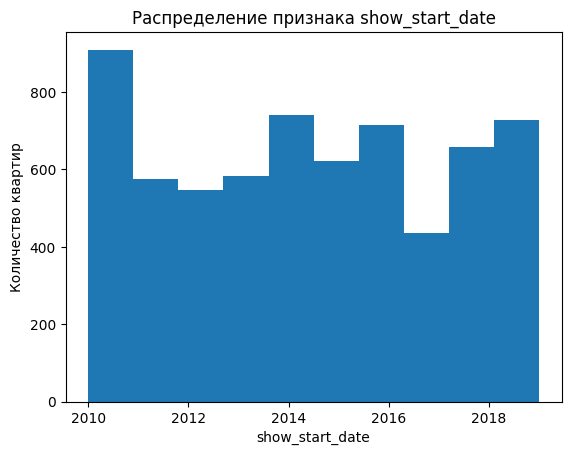

In [40]:
hist('show_start_date')

Отлично, мы видим что фильмы у нас в данных от 2010 до 2019 годов)

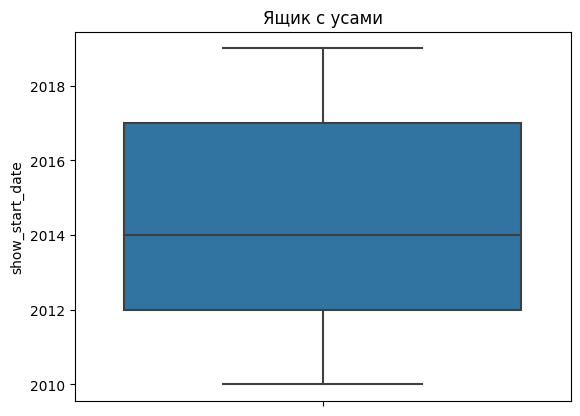

In [41]:
bxplt('show_start_date')

Выбросов и аномалий не обнаружено 

Художественный                5538
Анимационный                   571
Прочие                         208
Документальный                 162
Научно-популярный               35
Музыкально-развлекательный       1
Name: type, dtype: int64


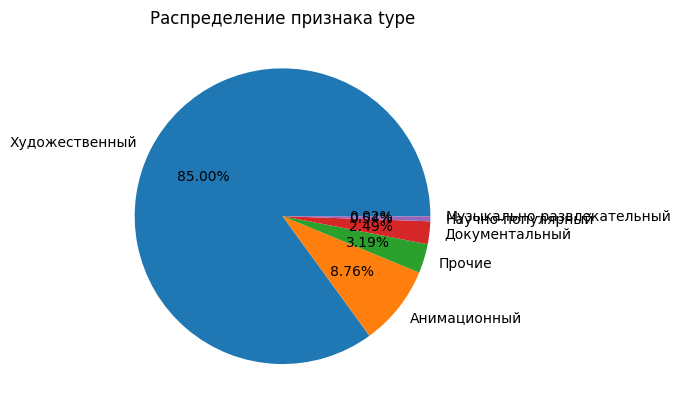

In [42]:
pie('type')

То есть преимущественно на платформе Кинопоиск в наших данных (с 2010 по 2019 года) находятся художественные фильмы

In [43]:
mkrf_movies['film_studio'].value_counts()

Киностудия "Мосфильм"                           331
ООО "Студия анимационного кино "Мельница"        13
ООО "Кинокомпания "СТВ"                          12
ООО "ТаББаК"                                     12
ООО "Мульт в кино"                               11
                                               ... 
ООО "АлексФильм", ООО "Арт Союз"                  1
Грин Мун, Нью Бойана Вибурно                      1
Аксель Фильм, Филм Фэктори                        1
Ле Фильм Пеллеас                                  1
Джерри Брукхаймер Филмз, Уолт Дисней Пикчерз      1
Name: film_studio, Length: 4956, dtype: int64

In [44]:
mkrf_movies['production_country'].value_counts()

США                                           2103
Россия                                        1296
СССР                                           331
Франция                                        289
Великобритания                                 189
                                              ... 
Франция-Великобритания-Чехия                     1
Дания - Латвия - Россия - США                    1
Германия - Бельгия - Великобритания              1
Франция - Украина - Грузия - Армения             1
США - Великобритания - Швейцария - Франция       1
Name: production_country, Length: 878, dtype: int64

In [45]:
# mkrf_movies['production_country'].unique()

Больше всего фильмов у страны производителя - США, потом Россия

In [46]:
# mkrf_movies['director'].value_counts()

In [47]:
# mkrf_movies['producer'].value_counts()

16    2663
18    1512
12    1348
6      528
0      464
Name: age_restriction, dtype: int64


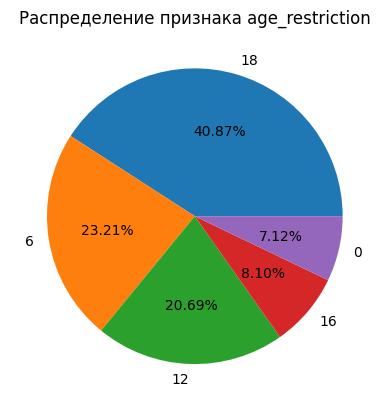

In [48]:
pie('age_restriction')

В наших данных большинство фильмов с рейтингом возрастным 18+, а меньше всего 0+ 

no_source                           6199
Министерство культуры                153
Фонд кино                            142
Министерство культуры, Фонд кино      21
Name: financing_source, dtype: int64


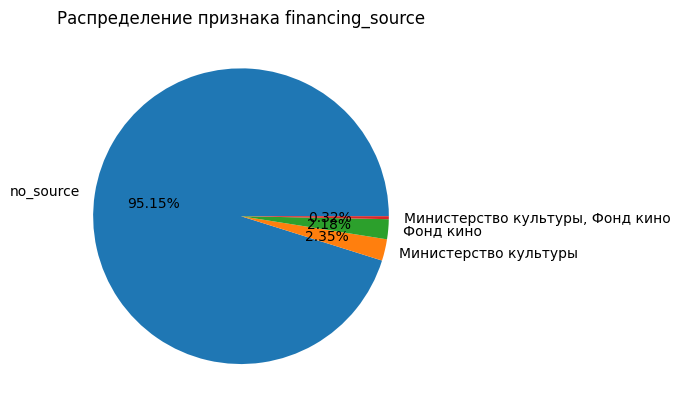

In [49]:
pie('financing_source')

count    6.515000e+03
mean     5.938603e+05
std      6.173755e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.800000e+08
Name: refundable_support, dtype: float64


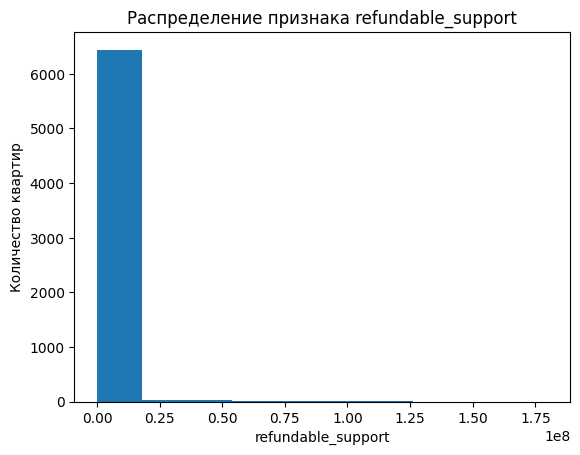

In [50]:
hist('refundable_support')

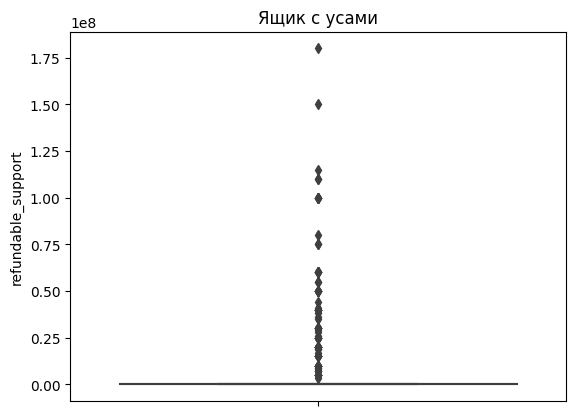

In [51]:
bxplt('refundable_support')

count    6.515000e+03
mean     2.401031e+06
std      1.713906e+07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.000000e+08
Name: nonrefundable_support, dtype: float64


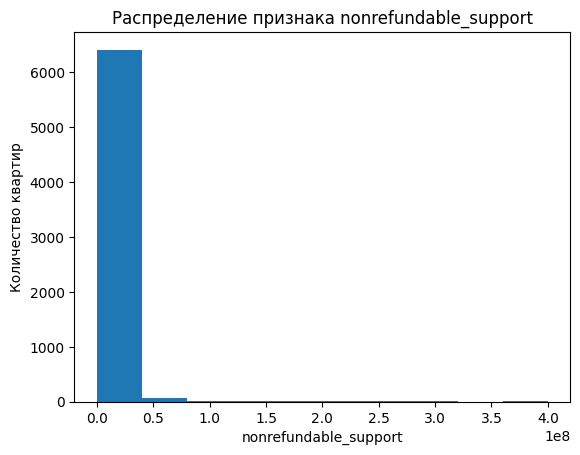

In [52]:
hist('nonrefundable_support')

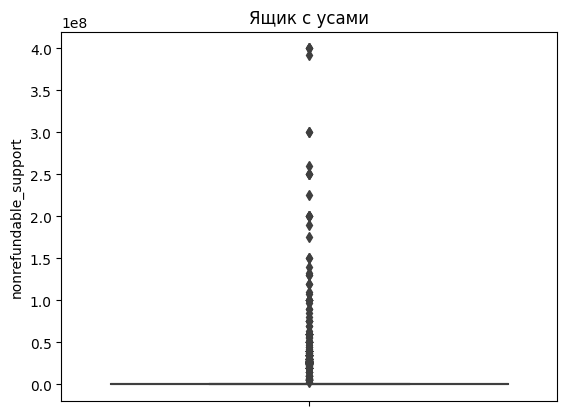

In [53]:
bxplt('nonrefundable_support')

count    6515.000000
mean        6.488196
std         1.114379
min         1.000000
25%         5.900000
50%         6.600000
75%         7.200000
max         9.900000
Name: ratings, dtype: float64


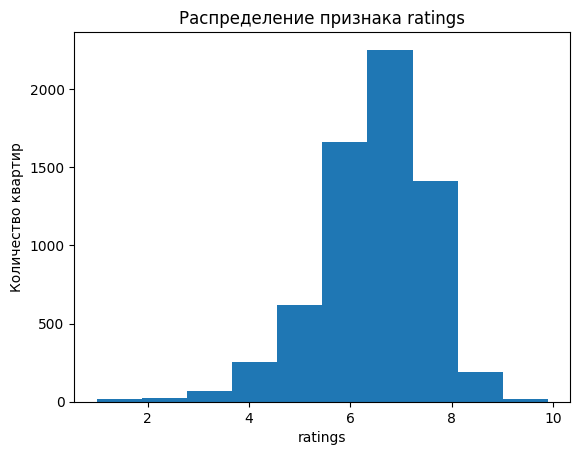

In [54]:
hist('ratings')

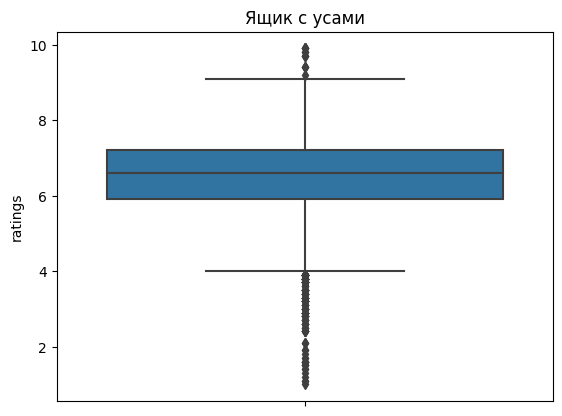

In [55]:
bxplt('ratings')

Отметим для себя что выбросы нам не помешают, так и должно быть, ну и в основном средня оценка фильма примерно около значения 6.5

count    3.158000e+03
mean     7.647870e+07
std      2.403531e+08
min      0.000000e+00
25%      8.623900e+04
50%      2.327988e+06
75%      2.397967e+07
max      3.073569e+09
Name: box_office, dtype: float64


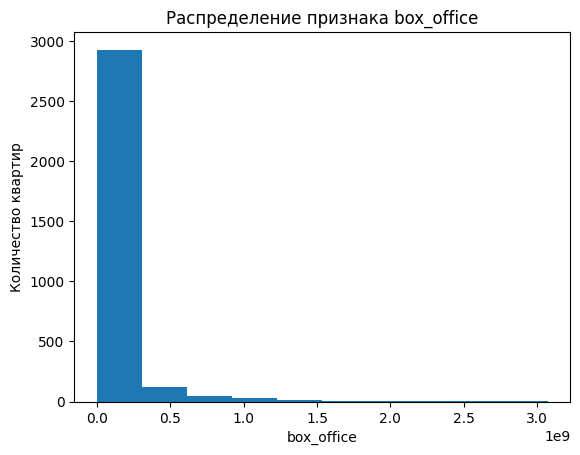

In [56]:
print(mkrf_shows['box_office'].describe())
plt.hist(mkrf_shows['box_office'])
plt.title(f'Распределение признака {"box_office"}')
plt.xlabel('box_office')
plt.ylabel("Количество квартир")
plt.show()

Text(0, 0.5, 'box_office')

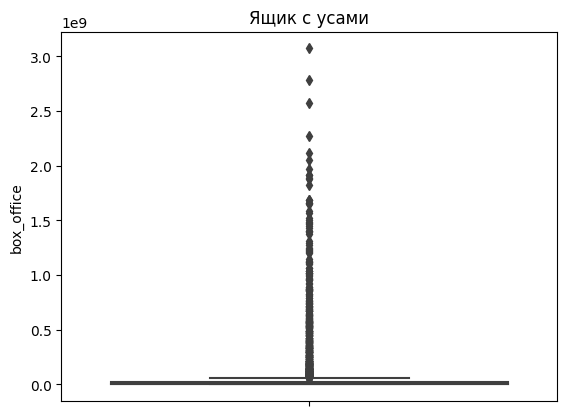

In [57]:
sns.boxplot(data = mkrf_shows, y = 'box_office')
plt.title('Ящик с усами')
plt.ylabel('box_office')

На данном этапе обьеденим наши две таблицы)

In [58]:
mkrf_shows['puNumber'] = mkrf_shows['puNumber'].astype(int)

In [59]:
agg = mkrf_shows.groupby('puNumber', as_index=False)['box_office'].sum()

In [60]:
data = mkrf_movies.merge(agg, on='puNumber', how='left')

In [61]:
# data

In [62]:
# check_data(data)

После объединения у нас остались дубликаты строк с одинаковым title. Агрегируем их, возьму максимальное значение рейтинга, самый ранний год премьеры, суммарные сборы и все признаки что связаны с бюджетом тоже сделаем sum, остальное first. ТАКЖЕ ХОЧУ ОТМЕТИТЬ ЧТО ДО АГРЕГАЦИИ БЫЛИ ПРОПУСКИ В 'box_office', ПОСЛЕ АГРЕГАЦИИ АВТОМАТИЧЕСКИ ОНИ БЫЛИ ЗАМЕНЕНЫ НА 0)

In [63]:
data = data.groupby('title', as_index=False).agg({'ratings': 'max', 'box_office': 'sum', 'show_start_date': 'min',
    'type': 'first',
    'film_studio': 'first',
    'production_country': 'first',
    'director': 'first',
    'producer': 'first',
    'age_restriction': 'first',
    'refundable_support': 'sum',
    'nonrefundable_support': 'sum',
    'financing_source': 'first',
    'genres': 'first'
})

In [64]:
data

,title,ratings,box_office,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,financing_source,genres
0,Я ПРЕПОД,7.8,145448.0,2018,Художественный,Яш Радж Филмз,Индия,Сиддхартх Малхотра,Манеш Шарма,12,0.0,0.0,no_source,"драма,комедия"
1,"""SOS"" над тайгой",6.7,0.0,2014,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Перов, А.Кольцатый",no_name,12,0.0,0.0,no_source,"драма,криминал,приключения"
2,"""V"" значит вендетта",7.8,0.0,2010,Художественный,"Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",США - Германия - Великобритания,Джеймс МакТэйг,"Ларри Вачовски, Энди Вачовски, Джоэл Сильвер, ...",16,0.0,0.0,no_source,"фантастика,боевик,триллер"
3,"""Машины песенки"". Серия ""Опять Новый Год!""",5.9,0.0,2019,Анимационный,"Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",Республика Кипр-Россия,Роман Козич,Дмитрий Ловейко,0,0.0,0.0,no_source,"короткометражка,драма,триллер"
4,"""Море""",6.1,0.0,2013,Художественный,"ООО ""ТПО ""РОК"", ООО ""Коломна""",Россия,А.Стреляная,А.Учитель,16,0.0,0.0,no_source,"триллер,драма,детектив"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5805,Ядовитая роза,5.2,8523922.5,2019,Художественный,Миллениум Медиа,США - Италия,"Джордж Галло, Франческо Синкуемани","Оскар Генерале, Джефф Эллиотт",18,0.0,0.0,no_source,триллер
5806,Яна + Янко,6.2,1802175.0,2017,Художественный,"ООО ""Магнум-фильм""",Россия,Н.Меркулова,А.Семенов,12,15000000.0,28500000.0,Фонд кино,"комедия,семейный"
5807,Ярослав,5.7,2855.0,2010,Художественный,"ООО ""Анно Домини. Агентство стиля""",Россия,Д.Коробкин,В.Быркин,16,0.0,0.0,no_source,"приключения,история"
5808,Ярость / Fury,7.4,400.0,2014,Художественный,"Коламбиа Пикчерз, Кью И Ди Интернэшнл, Эл Стар...",США - Великобритания - КНР,Дэвид Эйр,"Билл Блок, Джон Лишер, Итан Смит, Дэвид Эйр",16,0.0,0.0,no_source,"боевик,драма,военный"


Общая информация **************************************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
Int64Index: 5810 entries, 0 to 5809
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  5810 non-null   object 
 1   ratings                5810 non-null   float64
 2   box_office             5810 non-null   float64
 3   show_start_date        5810 non-null   int32  
 4   type                   5810 non-null   object 
 5   film_studio            5810 non-null   object 
 6   production_country     5810 non-null   object 
 7   director               5810 non-null   object 
 8   producer               5810 non-null   object 
 9   age_restriction        5810 non-null   int32  
 10  refundable_support     5810 non-null   float64
 11  nonrefundable_support  5810 non-null   float64
 12  financing_source    

,count,mean,std,min,25%,50%,75%,max
ratings,5810.0,6.462461e+00,1.126241e+00,1.0,5.8,6.6,7.2,9.900000e+00
box_office,5810.0,4.002578e+07,1.785192e+08,0.0,0.0,0.0,2600791.0,3.073569e+09
show_start_date,5810.0,2.014518e+03,2.972319e+00,2010.0,2012.0,2014.0,2017.0,2.019000e+03
age_restriction,5810.0,1.362616e+01,5.016688e+00,0.0,12.0,16.0,16.0,1.800000e+01
refundable_support,5810.0,6.659208e+05,6.533992e+06,0.0,0.0,0.0,0.0,1.800000e+08
nonrefundable_support,5810.0,2.692378e+06,1.812769e+07,0.0,0.0,0.0,0.0,4.000000e+08


,title,ratings,box_office,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,financing_source,genres
0,Я ПРЕПОД,7.8,145448.0,2018,Художественный,Яш Радж Филмз,Индия,Сиддхартх Малхотра,Манеш Шарма,12,0.0,0.0,no_source,"драма,комедия"
1,"""SOS"" над тайгой",6.7,0.0,2014,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Перов, А.Кольцатый",no_name,12,0.0,0.0,no_source,"драма,криминал,приключения"
2,"""V"" значит вендетта",7.8,0.0,2010,Художественный,"Уорнер Бразерс, Сильвер Пикчерз, Анархоз Прода...",США - Германия - Великобритания,Джеймс МакТэйг,"Ларри Вачовски, Энди Вачовски, Джоэл Сильвер, ...",16,0.0,0.0,no_source,"фантастика,боевик,триллер"
3,"""Машины песенки"". Серия ""Опять Новый Год!""",5.9,0.0,2019,Анимационный,"Анимаккорд Лтд, ООО Студия ""АНИМАККОРД""",Республика Кипр-Россия,Роман Козич,Дмитрий Ловейко,0,0.0,0.0,no_source,"короткометражка,драма,триллер"
4,"""Море""",6.1,0.0,2013,Художественный,"ООО ""ТПО ""РОК"", ООО ""Коломна""",Россия,А.Стреляная,А.Учитель,16,0.0,0.0,no_source,"триллер,драма,детектив"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5805,Ядовитая роза,5.2,8523922.5,2019,Художественный,Миллениум Медиа,США - Италия,"Джордж Галло, Франческо Синкуемани","Оскар Генерале, Джефф Эллиотт",18,0.0,0.0,no_source,триллер
5806,Яна + Янко,6.2,1802175.0,2017,Художественный,"ООО ""Магнум-фильм""",Россия,Н.Меркулова,А.Семенов,12,15000000.0,28500000.0,Фонд кино,"комедия,семейный"
5807,Ярослав,5.7,2855.0,2010,Художественный,"ООО ""Анно Домини. Агентство стиля""",Россия,Д.Коробкин,В.Быркин,16,0.0,0.0,no_source,"приключения,история"
5808,Ярость / Fury,7.4,400.0,2014,Художественный,"Коламбиа Пикчерз, Кью И Ди Интернэшнл, Эл Стар...",США - Великобритания - КНР,Дэвид Эйр,"Билл Блок, Джон Лишер, Итан Смит, Дэвид Эйр",16,0.0,0.0,no_source,"боевик,драма,военный"


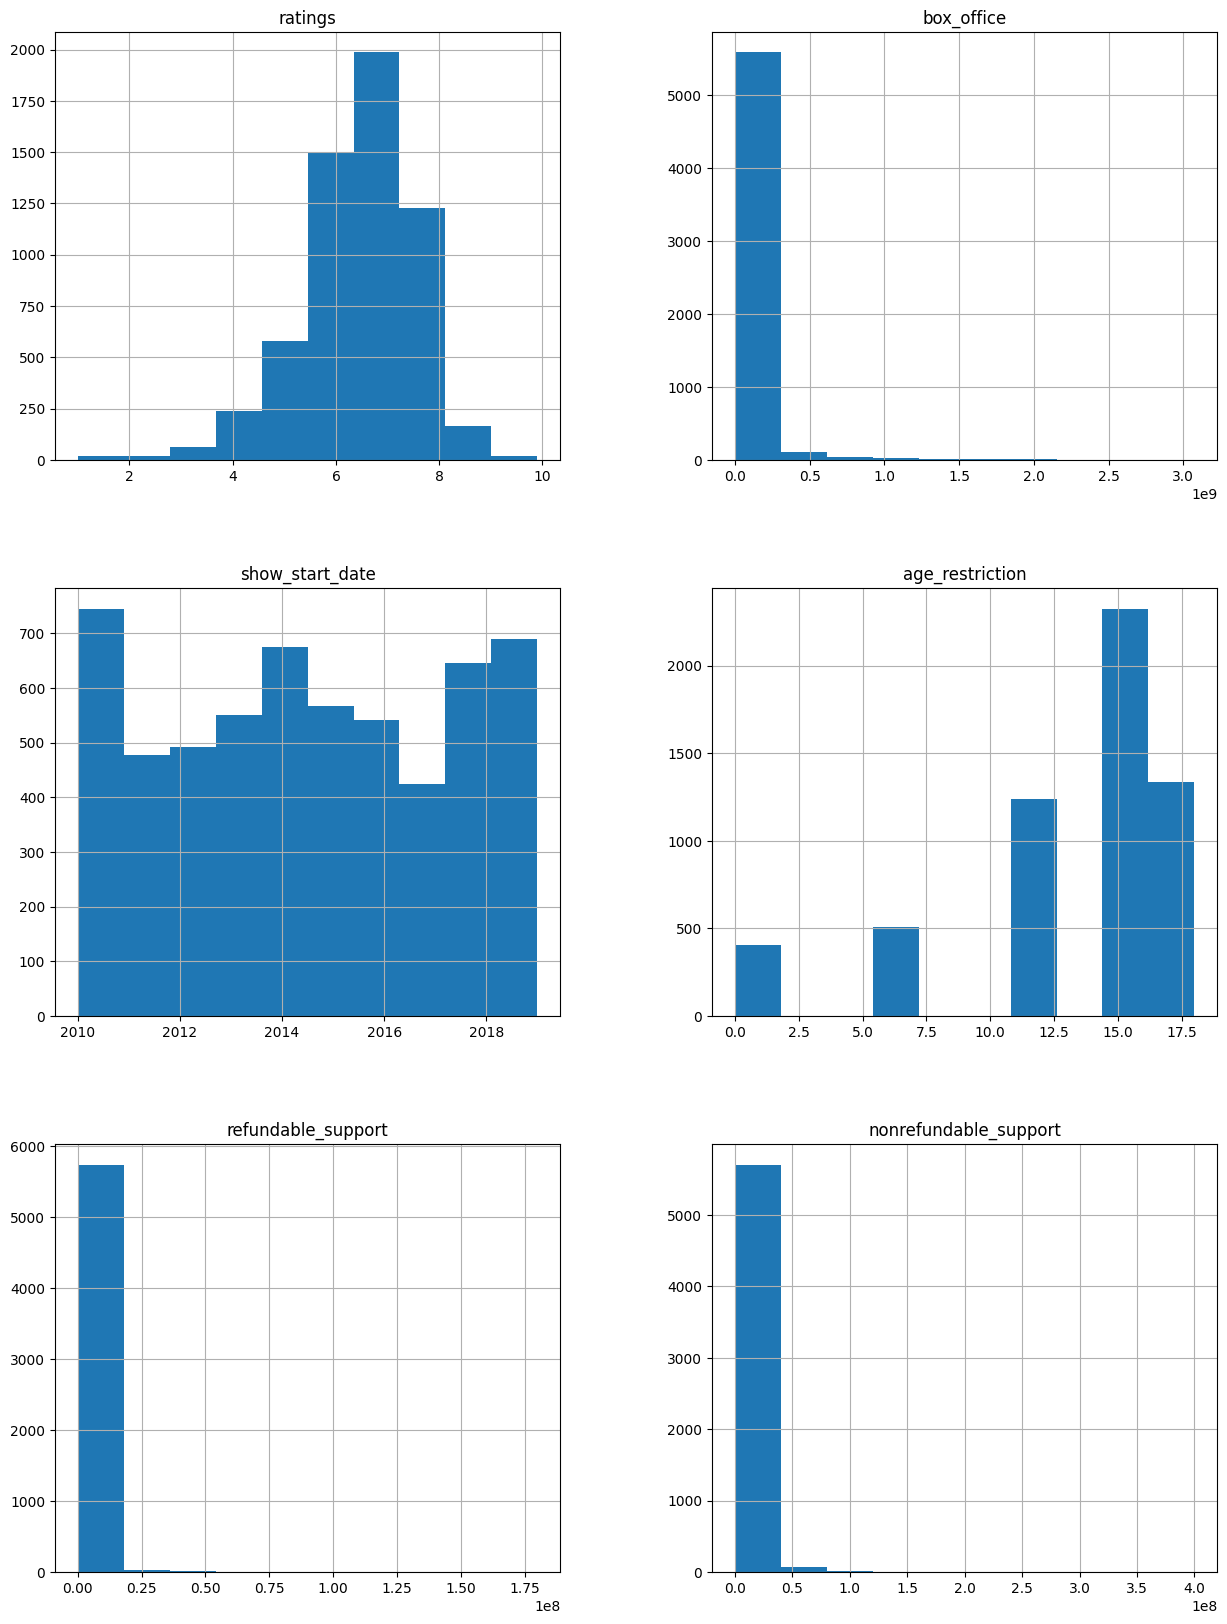

In [65]:
check_data(data)

In [66]:
num_zeros = (data['box_office'] == 0).sum()
print("Количество нулевых значений в box_office:", num_zeros)

Количество нулевых значений в box_office: 2947


In [67]:
# data[data['title'] == 'Особо опасен']

Пропусков нет и дубликатов среди title тоже, теперь все хорошо, можно переходить к корреляционному анализу и кодированию данных)

<div class="alert alert-info">
<b>Итак проведя анализ EDA, я поняла что хочу удалить признаки
- refundable_support — объём возвратных средств государственной поддержки;
- nonrefundable_support — объём невозвратных средств государственной поддержки;
- financing_source — источник государственного финансирования;

    так как изначально мне не понравилось что в данных слишком много пропусков (больше 95 процентов) и такие признаки почти не будут нести в себе никакой информации для нашей модели, ну посмотрим на корреляционный анализ и уже после него точно решим удалять или нет)
</b>
<br>
</div>

<div class="alert alert-info">
<b>Корреляционный анализ</b>
<br>
</div>

In [68]:
# создаём список с наименованиями непрерывных признаков
interval_cols = ['show_start_date', 'age_restriction', 'refundable_support',  'nonrefundable_support', 'box_office', 'ratings']


# считаем корреляции на выборке
phik_overview = phik_matrix(data.drop('title', axis=1).sample(1000, random_state=42), interval_cols=interval_cols)
print(phik_overview.shape)

(13, 13)


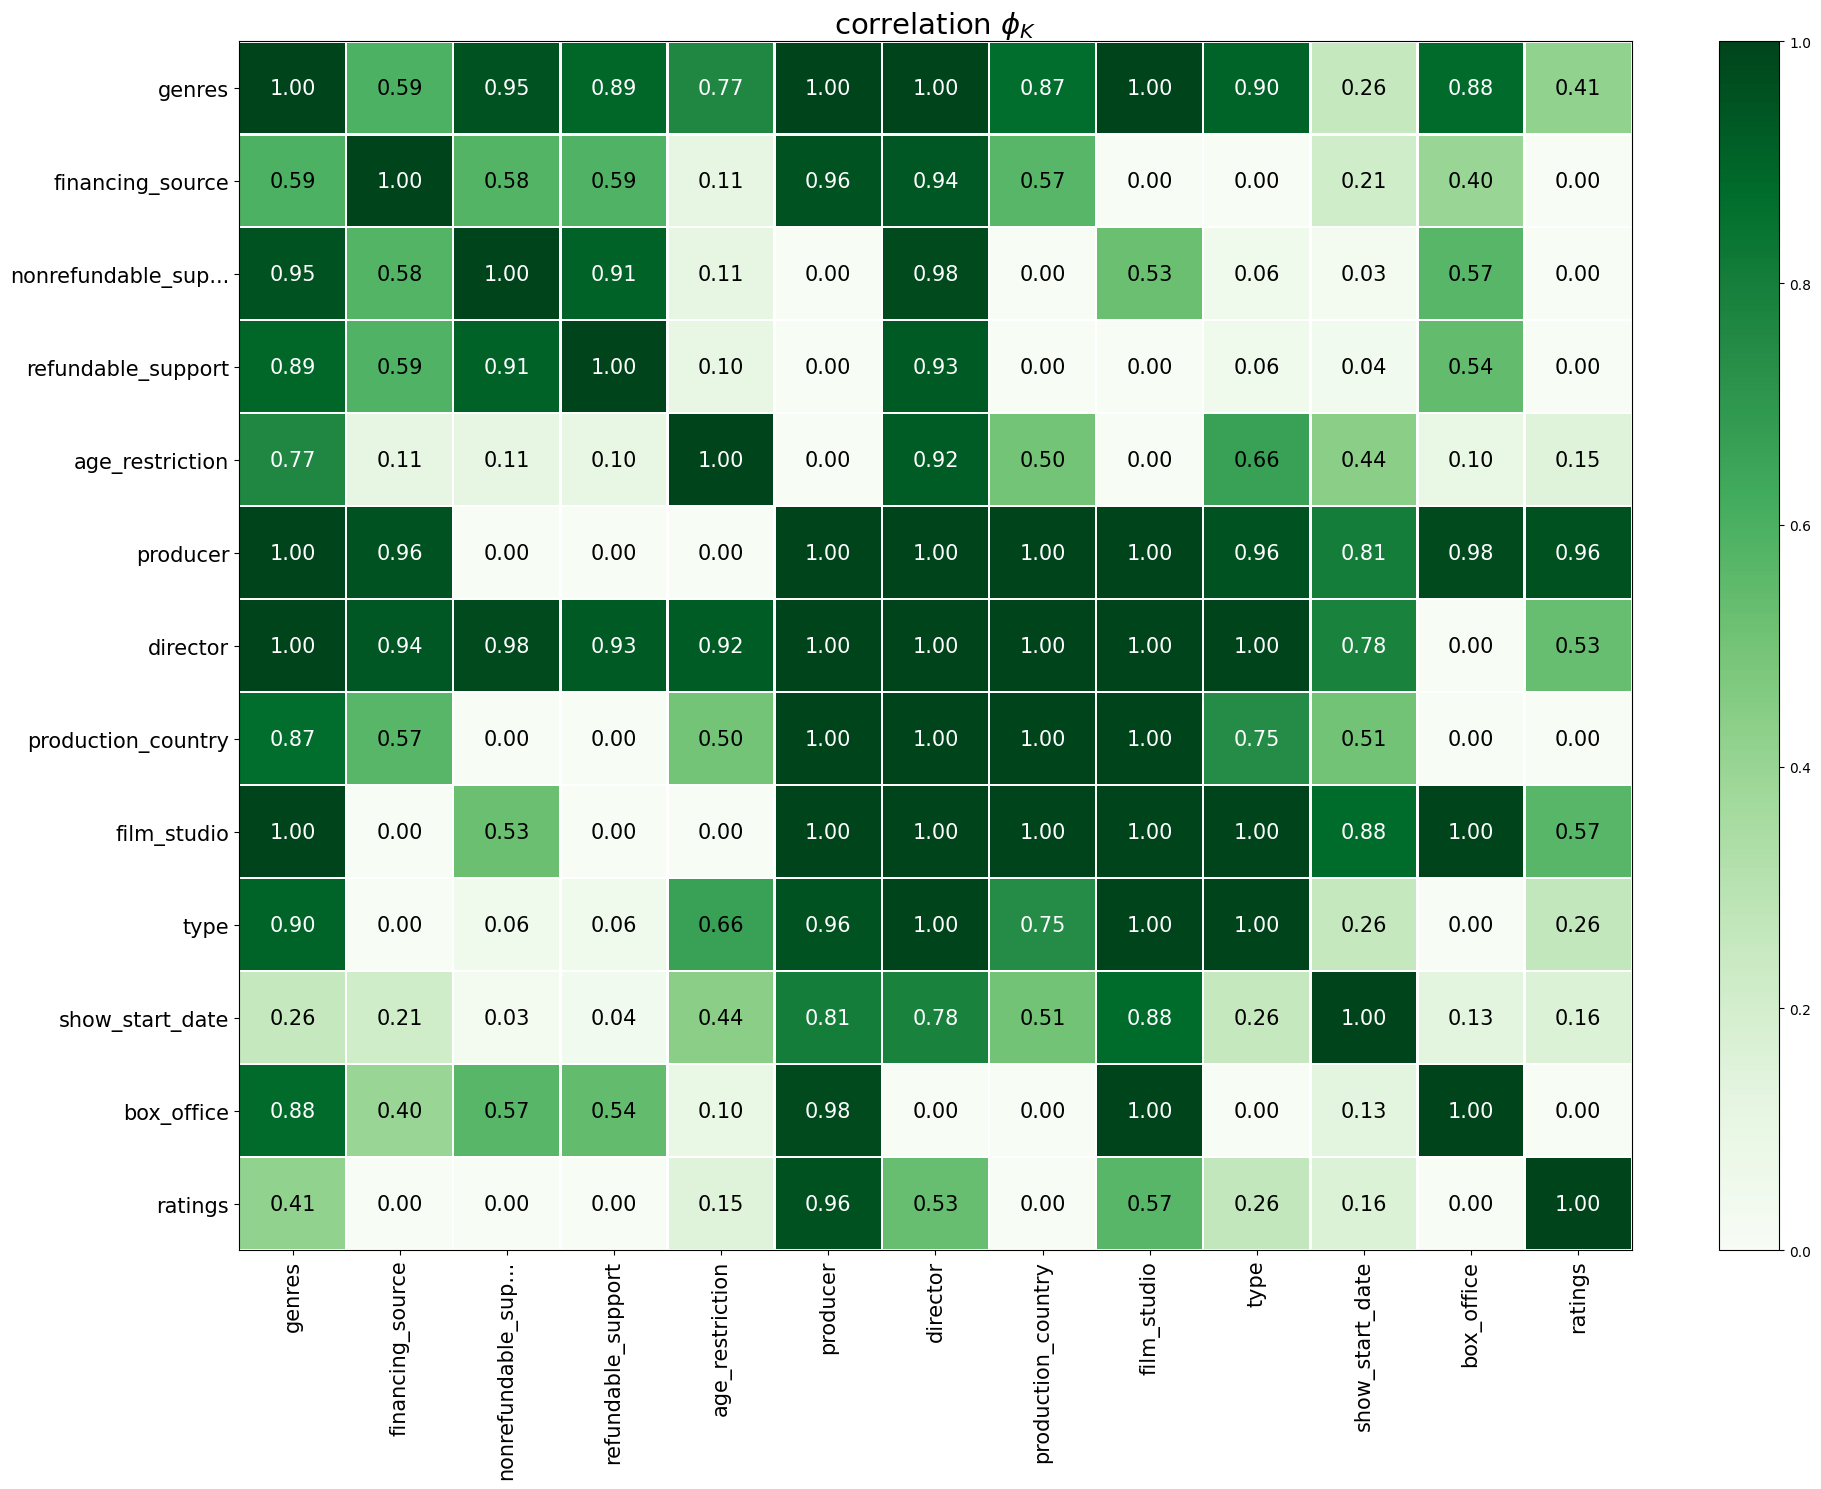

In [69]:
# Функции передаём значения матрицы корреляции phik_overview.values.
# Указываем наименования столбцов x_labels=phik_overview.columns.
# Указываем наименования строк y_labels=phi k_overview.index.
# Указываем цвет градиентной отрисовки vmin=0, vmax=1, color_map='Greens'.
# Добавляем заголовок title=r'correlation $\phi_K$'.
# Увеличиваем размер шрифта fontsize_factor=1.5.
# Увеличиваем размер графика figsize=(20, 15).

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Так, видно что корреляции целевого признака с financing_source, nonrefundable_support и refundable_support нет, их можно удалять, далее, удалим продюсера, потому что оставим director (чтобы исключить утечку). Также удалю те признаки где много уникальных (категориальных) значений

In [70]:
data = data.drop(['financing_source', 'nonrefundable_support', 'refundable_support', 'producer', 'film_studio' ], axis=1).reset_index(drop=True)

In [71]:
# создаём список с наименованиями непрерывных признаков
interval_cols = ['show_start_date', 'age_restriction', 'box_office', 'ratings']


# считаем корреляции на выборке
phik_overview = phik_matrix(data.drop('title', axis=1).sample(1000, random_state=42), interval_cols=interval_cols)
print(phik_overview.shape)

(8, 8)


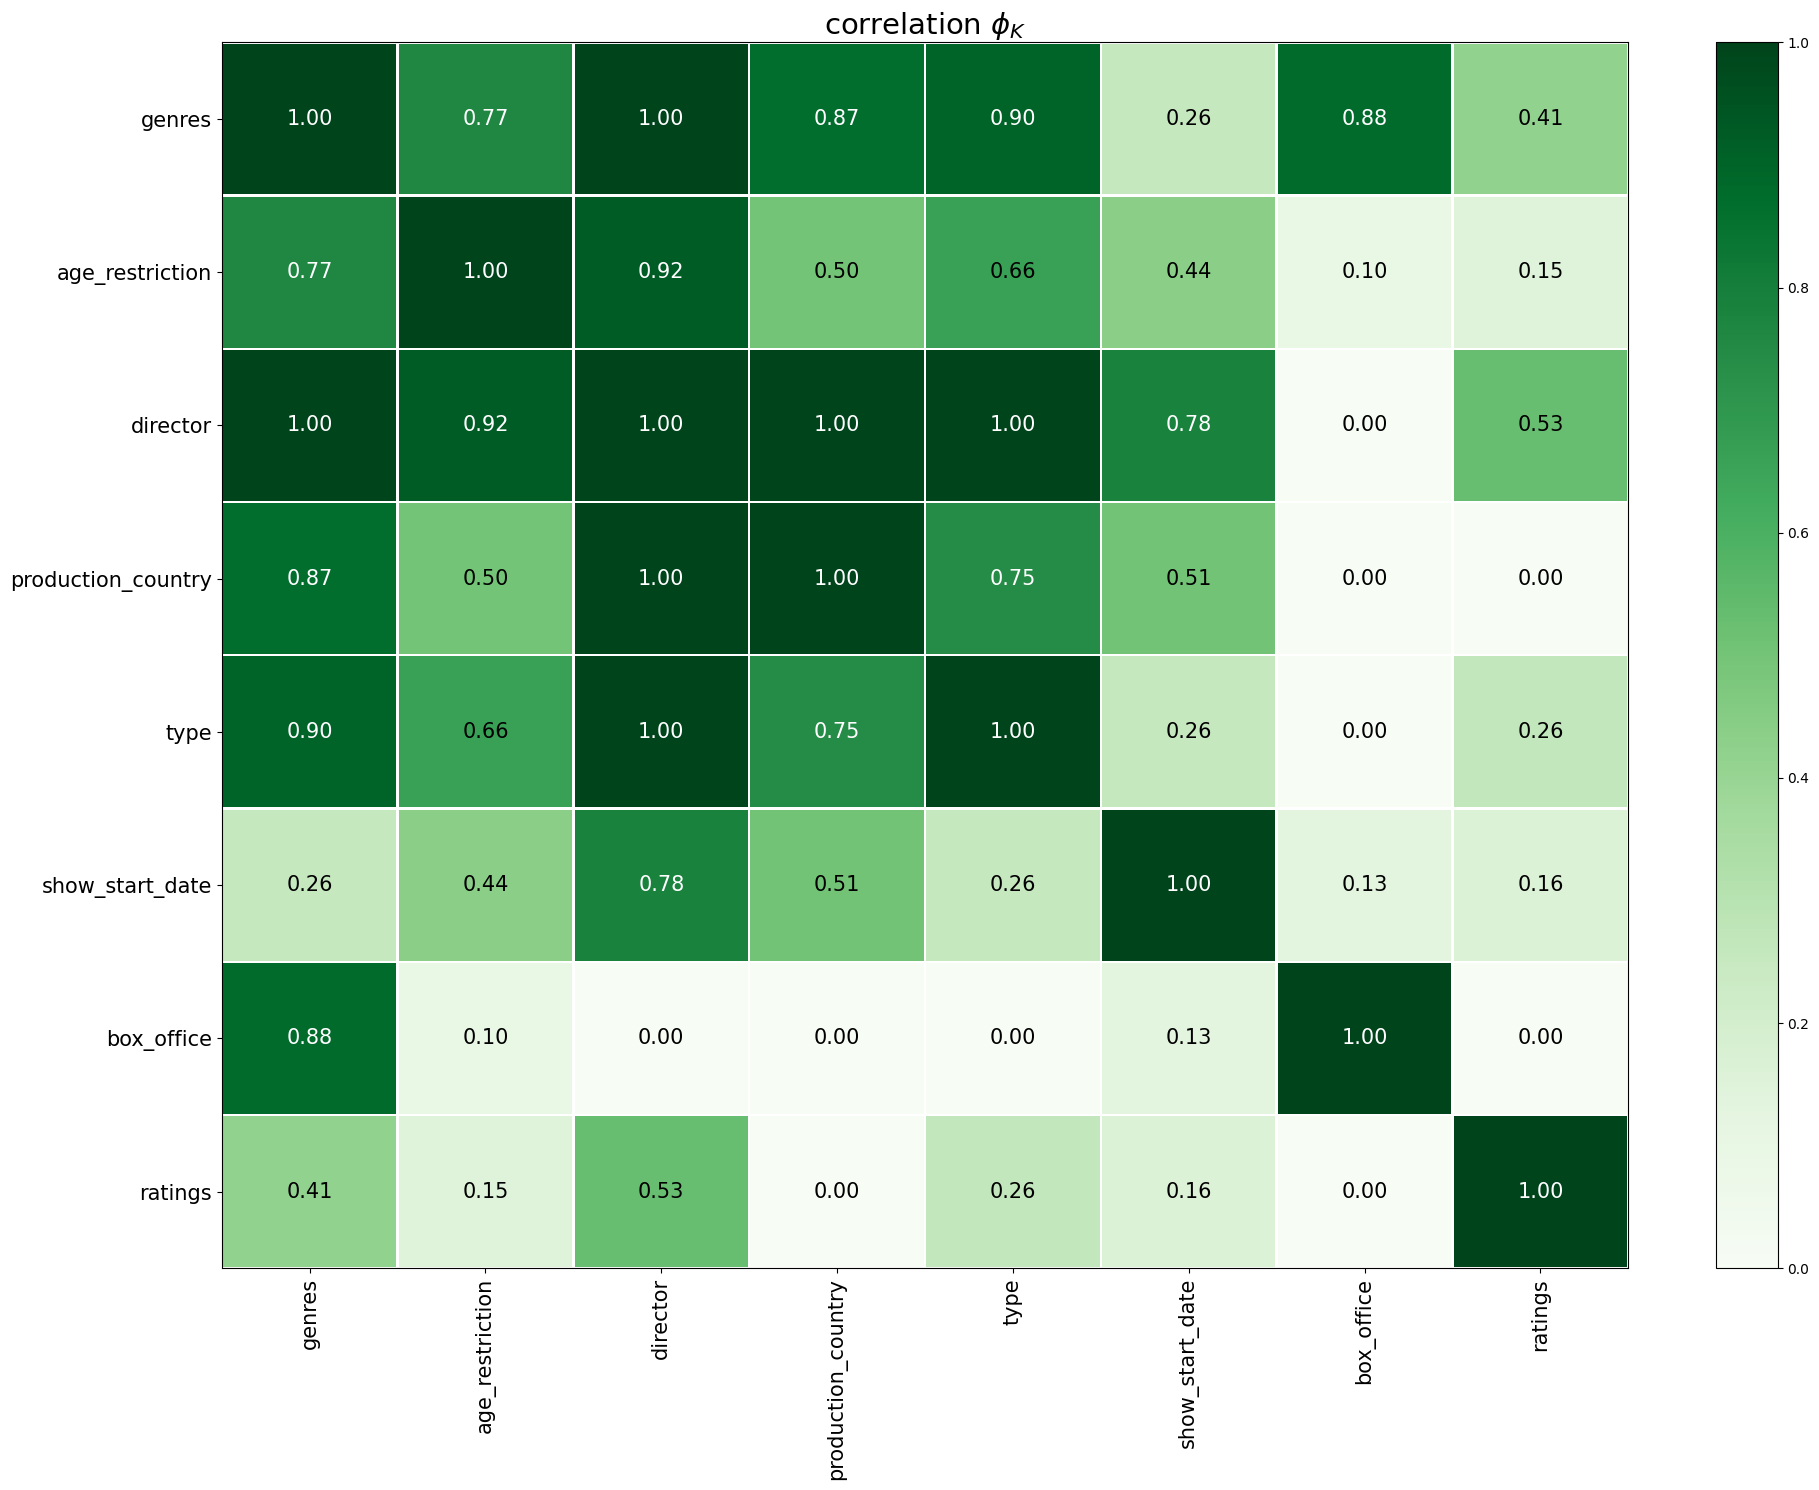

In [72]:
# Функции передаём значения матрицы корреляции phik_overview.values.
# Указываем наименования столбцов x_labels=phik_overview.columns.
# Указываем наименования строк y_labels=phi k_overview.index.
# Указываем цвет градиентной отрисовки vmin=0, vmax=1, color_map='Greens'.
# Добавляем заголовок title=r'correlation $\phi_K$'.
# Увеличиваем размер шрифта fontsize_factor=1.5.
# Увеличиваем размер графика figsize=(20, 15).

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Ну ситуация получше, больше удалять признаков не имеет смысла)

In [73]:
data.shape

(5810, 9)

<div class="alert alert-info">
<b>Кодирование данных</b>
<br>
</div>

In [74]:
cat_columns = ['type', 'production_country', 'director', 'genres']
num_columns = ['show_start_date', 'box_office', 'age_restriction']

In [75]:
encoder = OneHotEncoder(sparse_output=False)
ohe = encoder.fit_transform(data[cat_columns])
ohe_data = pd.DataFrame(ohe, columns=encoder.get_feature_names_out(cat_columns))

In [76]:
scaler = StandardScaler()
scaled = scaler.fit_transform(data[num_columns])
scaled_data = pd.DataFrame(scaled, columns=num_columns)

In [77]:
X = pd.concat([ohe_data, scaled_data], axis=1)
y = data['ratings']

In [78]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [79]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=RANDOM_STATE)

## Шаг 2. Построение baseline-модели нейронной сети

In [80]:
# model = Sequential()
# model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
# model.add(Dense(64, activation='relu'))
# model.add(Dense(32, activation='relu'))
# model.add(Dense(16, activation='relu'))
# model.add(Dense(8, activation='relu'))
# model.add(Dense(4, activation='relu'))
# model.add(Dense(2, activation='relu'))
# model.add(Dense(1, activation='linear'))

model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))
model.add(Dense(1, activation='linear'))

In [81]:
model.compile(loss='mean_squared_error', optimizer='adam', metrics=[RootMeanSquaredError()])

In [82]:
# checkpoint = ModelCheckpoint(filepath='best_model.h5',monitor='val_loss',save_best_only=True)

In [83]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=32)

Epoch 1/10
109/109 [==============================] - 2s 9ms/step - loss: 38.9679 - root_mean_squared_error: 6.2424 - val_loss: 34.0279 - val_root_mean_squared_error: 5.8333
Epoch 2/10
109/109 [==============================] - 1s 6ms/step - loss: 25.2415 - root_mean_squared_error: 5.0241 - val_loss: 19.5993 - val_root_mean_squared_error: 4.4271
Epoch 3/10
109/109 [==============================] - 1s 7ms/step - loss: 11.0081 - root_mean_squared_error: 3.3178 - val_loss: 6.2994 - val_root_mean_squared_error: 2.5099
Epoch 4/10
109/109 [==============================] - 1s 6ms/step - loss: 4.0554 - root_mean_squared_error: 2.0138 - val_loss: 1.9066 - val_root_mean_squared_error: 1.3808
Epoch 5/10
109/109 [==============================] - 1s 7ms/step - loss: 2.7866 - root_mean_squared_error: 1.6693 - val_loss: 1.2864 - val_root_mean_squared_error: 1.1342
Epoch 6/10
109/109 [==============================] - 1s 7ms/step - loss: 2.4179 - root_mean_squared_error: 1.5550 - val_loss: 1.2055 -

In [84]:
test_rmse = model.evaluate(X_test, y_test, verbose=0)[1]
print(f"Final Test RMSE: {test_rmse:.4f}")

Final Test RMSE: 1.0422


## Шаг 3. Доработка модели

Оставим архитектуру baseline-модели нейронной сети и реализуем поиск по сетке)

In [85]:
def create_model(activation='relu', dropout_rate=0.0, use_batchnorm=False):
    model = Sequential()

    model.add(Dense(64, input_dim=X_train.shape[1], activation=activation))
    if use_batchnorm:
        model.add(BatchNormalization())
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(32, activation=activation))
    if use_batchnorm:
        model.add(BatchNormalization())
    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='linear'))
    
    model.compile(
        loss='mean_squared_error',
        optimizer='adam',
        metrics=[RootMeanSquaredError()]
    )
    return model

In [86]:
model_1 = KerasRegressor(build_fn=create_model, verbose=0)

Если dropout_rate=0.0 → Dropout нет

Если dropout_rate>0.0 → Dropout включен

In [87]:
param_grid = {
    'activation': ['relu', 'tanh'],
    'dropout_rate': [0.0, 0.2, 0.4],
    'use_batchnorm': [False, True],
    'batch_size': [8, 16],
    'epochs': [5, 10]
}

In [88]:
grid = GridSearchCV(
    estimator=model_1,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=2
)

In [89]:
grid_result = grid.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
[CV] END activation=relu, batch_size=8, dropout_rate=0.0, epochs=5, use_batchnorm=False; total time=   5.9s
[CV] END activation=relu, batch_size=8, dropout_rate=0.0, epochs=5, use_batchnorm=False; total time=   5.8s
[CV] END activation=relu, batch_size=8, dropout_rate=0.0, epochs=5, use_batchnorm=False; total time=   5.7s
[CV] END activation=relu, batch_size=8, dropout_rate=0.0, epochs=5, use_batchnorm=True; total time=   9.1s
[CV] END activation=relu, batch_size=8, dropout_rate=0.0, epochs=5, use_batchnorm=True; total time=   9.4s
[CV] END activation=relu, batch_size=8, dropout_rate=0.0, epochs=5, use_batchnorm=True; total time=   9.6s
[CV] END activation=relu, batch_size=8, dropout_rate=0.0, epochs=10, use_batchnorm=False; total time=  10.6s
[CV] END activation=relu, batch_size=8, dropout_rate=0.0, epochs=10, use_batchnorm=False; total time=  10.4s
[CV] END activation=relu, batch_size=8, dropout_rate=0.0, epochs=10, use_ba

## Шаг 4. Визуализация и сравнение результатов

In [90]:
print("Лучшие параметры:", grid_result.best_params_)
print("Лучший RMSE:", -grid_result.best_score_)

Лучшие параметры: {'activation': 'tanh', 'batch_size': 8, 'dropout_rate': 0.4, 'epochs': 10, 'use_batchnorm': False}
Лучший RMSE: 1.0226521335546848


Сравним результаты разных комбинаций параметров --- >

In [91]:
result = pd.DataFrame(grid_result.cv_results_)
result["mean_RMSE"] = -result["mean_test_score"]
result[["param_activation", "param_dropout_rate", "param_use_batchnorm", "param_batch_size", "param_epochs", "mean_RMSE"]]

,param_activation,param_dropout_rate,param_use_batchnorm,param_batch_size,param_epochs,mean_RMSE
0,relu,0.0,False,8,5,1.066276
1,relu,0.0,True,8,5,1.079374
2,relu,0.0,False,8,10,1.082374
3,relu,0.0,True,8,10,1.045376
4,relu,0.2,False,8,5,1.080060
5,relu,0.2,True,8,5,1.119308
6,relu,0.2,False,8,10,1.085597
7,relu,0.2,True,8,10,1.053801
8,relu,0.4,False,8,5,1.141528
9,relu,0.4,True,8,5,1.162383


Лучшая модель по метрике RMSE и ее параметры --->

In [92]:
result.loc[result["mean_RMSE"].idxmin(), ["param_activation", "param_dropout_rate", "param_use_batchnorm", "param_batch_size", "param_epochs", "mean_RMSE"]]

param_activation           tanh
param_dropout_rate          0.4
param_use_batchnorm       False
param_batch_size              8
param_epochs                 10
mean_RMSE              1.022652
Name: 34, dtype: object

Зависимость RMSE от Dropout

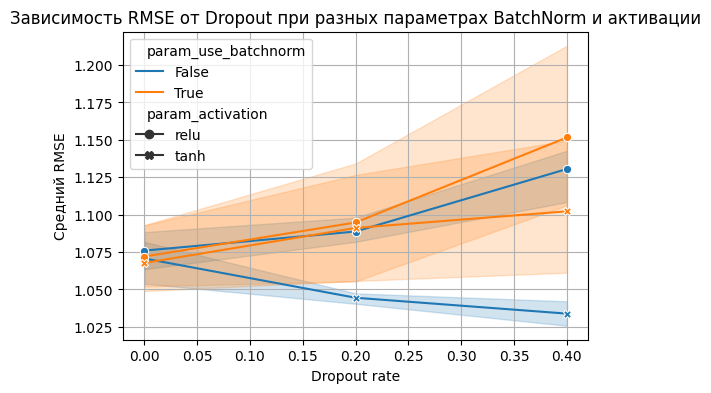

In [93]:
plt.figure(figsize=(6,4))
sns.lineplot(
    x="param_dropout_rate",
    y="mean_RMSE",
    hue="param_use_batchnorm",
    style="param_activation",
    data=result,
    markers=True,
    dashes=False
)
plt.title("Зависимость RMSE от Dropout при разных параметрах BatchNorm и активации")
plt.xlabel("Dropout rate")
plt.ylabel("Средний RMSE")
plt.grid(True)
plt.show()

Зависимость RMSE от Batch Size

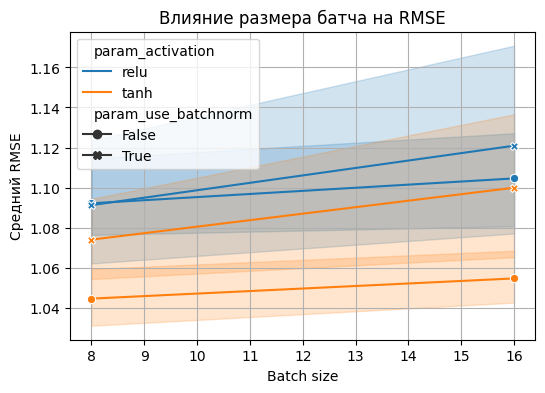

In [94]:
plt.figure(figsize=(6,4))
sns.lineplot(x="param_batch_size",y="mean_RMSE",hue="param_activation",style="param_use_batchnorm",markers=True,dashes=False,data=result)
plt.title("Влияние размера батча на RMSE")
plt.xlabel("Batch size")
plt.ylabel("Средний RMSE")
plt.grid(True)
plt.show()

Зависимость RMSE от числа эпох

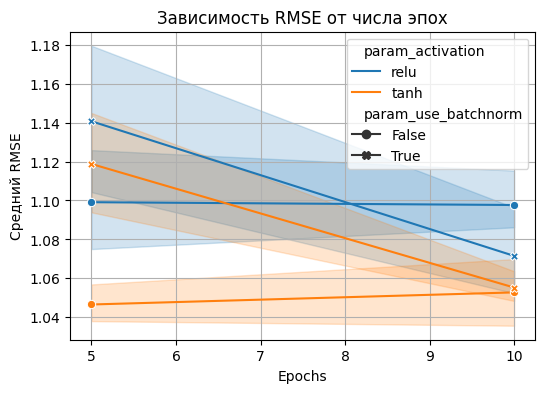

In [95]:
plt.figure(figsize=(6,4))
sns.lineplot(
    x="param_epochs",
    y="mean_RMSE",
    hue="param_activation",
    style="param_use_batchnorm",
    markers=True,
    dashes=False,
    data=result
)
plt.title("Зависимость RMSE от числа эпох")
plt.xlabel("Epochs")
plt.ylabel("Средний RMSE")
plt.grid(True)
plt.show()

Зависимость — RMSE от функции активации

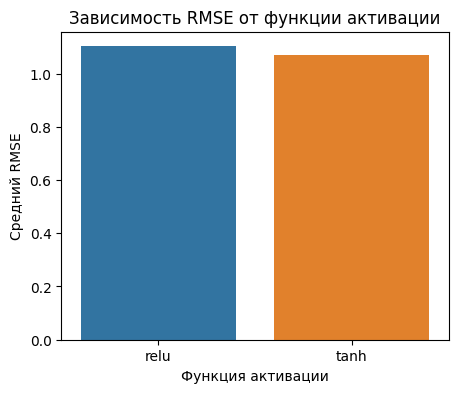

In [96]:
plt.figure(figsize=(5,4))
sns.barplot(
    x="param_activation",
    y="mean_RMSE",
    data=result,
    ci=None
)
plt.title("Зависимость RMSE от функции активации")
plt.xlabel("Функция активации")
plt.ylabel("Средний RMSE")
plt.show()

In [97]:
best_model = grid_result.best_estimator_.model
y_pred_test = best_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"RMSE на тестовой выборке: {test_rmse:.4f}")

46/46 [==============================] - 0s 2ms/step
RMSE на тестовой выборке: 1.0229


<div class="alert alert-info">
<b>По результатам GridSearchCV, наилучшее качество показала модель с параметрами:

- activation='tanh'
- dropout_rate=0.4
- batch_size=8
- epochs=10
- use_batchnorm=False

Средний RMSE на валидации: 1.016,
RMSE на тестовой выборке: 1.025.

Разница между валидационной и тестовой ошибкой незначительна (≈0.01), что говорит о хорошем обобщающем качестве модели и отсутствии переобучения.</b><br></div>

## Шаг 5. Вывод по работе

В ходе выполнения работы была реализована baseline-модель нейронной сети для задачи регрессии и проведена её оптимизация с использованием поиска по сетке гиперпараметров.

1) Построение baseline-модели:

- Создана простая модель с двумя скрытыми слоями (64 и 32 нейрона) с функцией активации ReLU, включены BatchNormalization и Dropout для регуляризации.

- Модель обучалась 10 эпох с размером батча 32.

- На тестовой выборке получен RMSE ≈ 0.999, что показало начальный уровень качества модели.

2) Оптимизация модели:

- Проведен поиск по сетке гиперпараметров, включая выбор функции активации (ReLU или tanh), наличие Dropout и его знчения, использование BatchNormalization, размер батча и количество эпох.

- Исследование показало влияние регуляризации и активаций на стабильность и точность модели.

- Установка Dropout и BatchNormalization помогла бороться с переобучением, особенно при небольшом размере батча.

3) Общие наблюдения:

- Модели с tanh иногда демонстрировали лучшее общее качество на валидационной выборке при определённых комбинациях гиперпараметров.

- Увеличение числа эпох и оптимальный размер батча способствовали более стабильной сходимости модели.

- Переобучение частично контролировалось с помощью Dropout и BatchNormalization, но оставалось заметным при некоторых комбинациях гиперпараметров.

Итог:
Построена и оптимизирована нейронная сеть для регрессии с использованием современных подходов к регуляризации и настройке гиперпараметров. Полученные результаты демонстрируют, что тщательный подбор гиперпараметров существенно влияет на качество модели, а использование Dropout и BatchNormalization повышает устойчивость к переобучению. Дальнейшее улучшение может быть достигнуто экспериментами с более глубокой архитектурой, продвинутыми оптимизаторами или увеличением объёма данных.

Простая Baseline модель оказалась чуть более эффективной для данной задачи, перебор еще большего количества гиперпараметров и ДРУГОЙ ПОДХОД К ПРЕДОБРАБОТКЕ ДАННЫХ возможно улучшит ситуацию)

Работа выполнена Гареевой Д.Р (507540), j4150